# Reverse Diffusion: Training-Free Score Estimation

- 신경망 없이 score $s(x,t) = \nabla_x \log p_t(x)$를 추정하는 방법 구현  
- Euler-Maruyama와 Probability Flow ODE(RK4)로 reverse diffusion을 비교

| Case | Score 추정 방법 |
|------|----------------|
| 0 | GMM 해석적 score (기준선) |
| 1 | Fokker-Planck PDE 수치적분 → $p_t$ |
---

### 초기 세팅

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


# ── dataset setting ───────────────────────────────────────────────────────────
def make_samples(means, std, n_per_mode):
    return np.vstack([mu + rng.standard_normal((n_per_mode, 2)) * std for mu in means])


# Grid
g = np.linspace(-2, 2, 3)
grid_means = np.array([[x, y] for y in g for x in g])

# Moons
th = np.linspace(0, np.pi, 300)
moon_means = np.vstack(
    [
        np.column_stack([np.cos(th), np.sin(th)]),
        np.column_stack([1 - np.cos(th), 1 - np.sin(th) - 0.5]),
    ]
)

# Heart
t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
heart_means = (
    np.column_stack(
        [
            16 * np.sin(t) ** 3,
            13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t),
        ]
    )
    / 10
)

datasets = {
    "grid": make_samples(grid_means, std=0.12, n_per_mode=150),
    "moons": make_samples(moon_means, std=0.06, n_per_mode=1),
    "heart": make_samples(heart_means, std=0.07, n_per_mode=80),
}

# ── Noise schedule ────────────────────────────────────────────────────────────
T = 500
betas = np.linspace(1e-4, 0.02, T)
alpha_bar = np.cumprod(1 - betas)
sigma2_t = 1 - alpha_bar

SAVE_STEPS = [0, 100, 200, 300, 400, 500]

## Forward VP-SDE

$$dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}dW$$

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \bar{\alpha}_t = \prod_{s=1}^t\alpha_s$$
---

In [8]:
# ── Forward SDE ───────────────────────────────────────────────────────────────
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i, beta in enumerate(betas):
        x = x * (1 - 0.5 * beta) + np.sqrt(beta) * rng.standard_normal(x.shape)
        t = i + 1
        saved[t] = x.copy()
    return saved

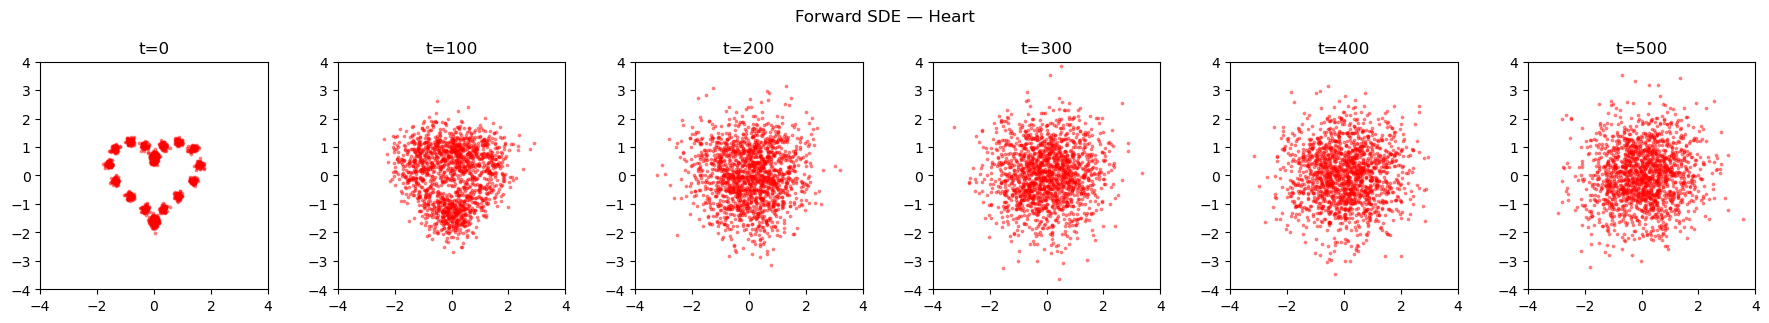

In [9]:
# ── Heart forward 확인 ────────────────────────────────────────────────────────
fwd = {}
for name, x0 in datasets.items():
    fwd[name] = forward_sde(x0)


fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, t in zip(axes, SAVE_STEPS):
    refs = fwd["heart"][t]
    ax.scatter(*refs.T, s=3, alpha=0.4, c='red')
    ax.set_title(f"t={t}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
fig.suptitle("Forward SDE — Heart", y=1.01)
plt.tight_layout()
plt.show()

## Forward VP-SDE 수식 증명

### Forward VP-SDE
$$
dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}dW
$$

$$
x_t-x_{t-1}=-\frac{1}{2}\beta_t x_{t-1}+\sqrt{\beta_t}\epsilon
$$

$$
x_t=\left(1-\frac{1}{2}\beta_t \right) x_{t-1}+\sqrt{\beta_t}\epsilon
$$
<br>
    
$1-\frac{1}{2}\beta_t \equiv \sqrt{1-\beta_t}$ ($\beta_t$가 작을 때) 이므로:  
$$
x_t=\sqrt{1-\beta_t}x_{t-1}+\sqrt{\beta_t}\epsilon
= \sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon
$$
$$\alpha_t = 1 - \beta_t$$



### 한 스텝 점화식
 
$$\mathbf{x}_t = \sqrt{\alpha_t}\,\mathbf{x}_{t-1} + \sqrt{1-\alpha_t}\,\boldsymbol{\epsilon}_t, \qquad \boldsymbol{\epsilon}_t \sim \mathcal{N}(0,I)$$
 
### 반복 대입
 
**$t=1$:**
 
$$\mathbf{x}_1 = \sqrt{\alpha_1}\,\mathbf{x}_0 + \sqrt{1-\alpha_1}\,\boldsymbol{\epsilon}_1$$
 
**$t=2$:** $\mathbf{x}_1$을 대입:
 
$$\mathbf{x}_2 = \sqrt{\alpha_2}\,\mathbf{x}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2$$
 
$$= \sqrt{\alpha_2}\left(\sqrt{\alpha_1}\,\mathbf{x}_0 + \sqrt{1-\alpha_1}\,\boldsymbol{\epsilon}_1\right) + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2$$
 
$$= \sqrt{\alpha_1\alpha_2}\,\mathbf{x}_0 + \underbrace{\sqrt{\alpha_2(1-\alpha_1)}\,\boldsymbol{\epsilon}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2}_{\text{두 독립 가우시안의 합}}$$
 
### 노이즈 항 합치기
 
두 독립 가우시안의 합의 분산:
 
$$\text{Var} = \alpha_2(1-\alpha_1) + (1-\alpha_2) = \alpha_2 - \alpha_1\alpha_2 + 1 - \alpha_2 = 1 - \alpha_1\alpha_2$$
 
따라서 두 노이즈를 하나의 가우시안으로 합칠 수 있다:
 
$$\sqrt{\alpha_2(1-\alpha_1)}\,\boldsymbol{\epsilon}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2 = \sqrt{1-\alpha_1\alpha_2}\,\boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon}\sim\mathcal{N}(0,I)$$
 
따라서:
 
$$\mathbf{x}_2 = \sqrt{\alpha_1\alpha_2}\,\mathbf{x}_0 + \sqrt{1-\alpha_1\alpha_2}\,\boldsymbol{\epsilon}$$

### 일반화
 
같은 과정을 $t$번 반복하면 노이즈 항의 분산이:
 
$$1-\alpha_1\alpha_2, \quad 1-\alpha_1\alpha_2\alpha_3, \quad \ldots, \quad 1-\prod_{s=1}^t\alpha_s = 1-\bar{\alpha}_t$$
 
따라서:
 
$$\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \bar{\alpha}_t = \prod_{s=1}^t\alpha_s}$$

## Reverse SDE (Anderson, 1982)

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

---

## Euler-Maruyama (SDE Solver)
$$x_{t-1} = x_t + \beta_t\!\left(-\tfrac{1}{2}x_t - s(x_t,t)\right)\Delta t + \sqrt{\beta_t\Delta t}\,\epsilon$$
---

In [ ]:
def reverse_euler(x_T, score_fn):
    """Euler-Maruyama (stochastic SDE)"""
    traj = {T: x_T.copy()}
    x = x_T.copy()
    for t_idx in reversed(range(T)):
        b = betas[t_idx]
        s = score_fn(x, t_idx)
        x = x + b * (-0.5 * x - s) + np.sqrt(b) * rng.standard_normal(x.shape)
        traj[t_idx] = x.copy()
    return traj

## Probability Flow ODE (RK4: ODE Solver)
### 핵심 목표
 
**노이즈를 없애되, $p_t$의 시간 변화는 동일하게 유지**
 
SDE와 ODE는 서로 다른 방정식이지만, **Fokker-Planck 수준에서 일치하면 같은 $p_t$를 만들어냄.**

$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$
 
---

In [14]:
# RK4
def ODE_MV_RK4(f, r, t, *args):
    h = t[1] - t[0]
    k = np.zeros((4, *r.shape[1:]), float)
    for i in range(len(t) - 1):
        k[0] = h * f(r[i], t[i], *args)
        k[1] = h * f(r[i] + k[0] / 2, t[i] + h / 2, *args)
        k[2] = h * f(r[i] + k[1] / 2, t[i] + h / 2, *args)
        k[3] = h * f(r[i] + k[2], t[i] + h, *args)
        r[i + 1] = r[i] + (k[0] + 2 * k[1] + 2 * k[2] + k[3]) / 6
    return r


# Probability Flow ODE 우변: dx/dt = -β(t)/2 · x - β(t)/2 · s(x,t)
def PF_ODE(x, t_cont, score_fn):
    t_idx = int(np.clip(round(t_cont), 0, T - 1))
    b = betas[t_idx]
    s = score_fn(x, t_idx)
    return -0.5 * b * x - 0.5 * b * s


def reverse_rk4(x_T, score_fn):
    """Probability Flow ODE (deterministic), RK4 적분"""

    t_arr = np.arange(T, -1, -1)
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = ODE_MV_RK4(PF_ODE, r, t_arr, score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[t] = r[i].copy()
    return traj

## Probability Flow ODE 증명

### Step 1: Reverse SDE의 Fokker-Planck 방정식
 
Reverse SDE:
 
$$dx = \underbrace{\left[-\frac{1}{2}\beta x - \beta s\right]}_{f}\,dt + \underbrace{\sqrt{\beta}}_{g}\,d\bar{W}$$
 
이 SDE의 Fokker-Planck 방정식:
 
$$\frac{\partial p}{\partial t} = \underbrace{-\nabla\cdot(f\cdot p)}_{\text{drift 기여}} + \underbrace{\frac{1}{2}g^2\,\nabla^2 p}_{\text{노이즈 기여}}$$
 
---
 
### Step 2: ODE의 Fokker-Planck 방정식
 
ODE $\dfrac{dx}{dt} = \tilde{f}$의 Fokker-Planck:
 
$$\frac{\partial p}{\partial t} = -\nabla\cdot(\tilde{f}\cdot p)$$
 
노이즈가 없으니 두 번째 항이 없음.
 
---
 
### Step 3: 두 Fokker-Planck를 같게 놓기
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \frac{1}{2}g^2\,\nabla^2 p$$
 
우변의 노이즈 항 $\dfrac{1}{2}g^2\,\nabla^2 p$을 $-\nabla\cdot(\cdot\, p)$ 꼴로 변환.
 
$$\frac{1}{2}g^2\,\nabla^2 p = \frac{1}{2}g^2\,\nabla\cdot(\nabla p)$$
 
여기서 $\nabla p = p \cdot \nabla\log p = p \cdot s$ 이므로:
 
$$= \nabla\cdot\!\left(\frac{1}{2}g^2\, s\cdot p\right)$$
 
따라서:
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \nabla\cdot\!\left(\frac{1}{2}g^2\,s\cdot p\right) = -\nabla\cdot\!\left[\left(f - \frac{1}{2}g^2\,s\right)p\right]$$
 
$$\boxed{\tilde{f} = f - \frac{1}{2}g^2\,s}$$
 
---
 
### Step 4: 대입
 
$f = -\dfrac{1}{2}\beta x - \beta s$, $\quad g^2 = \beta$ 를 대입:
 
$$\tilde{f} = \left(-\frac{1}{2}\beta x - \beta s\right) - \frac{1}{2}\beta s = -\frac{1}{2}\beta x - \frac{1}{2}\beta s$$
 
최종 Probability Flow ODE:
 
$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$
 

---
## Case 0 — GMM Exact Score + Euler vs RK4

VP-SDE의 marginal(주변분포, $x_t$)은 GMM(Gaussian Mixture Model)을 유지:
$$p_t(x) = \frac{1}{K}\sum_k \mathcal{N}\!\left(x;\;\sqrt{\bar\alpha_t}\mu_k,\;\bar\alpha_t\sigma_k^2 + \sigma_t^2\right)$$

Score는 각 모드 score의 **사후확률 가중 합**:
$$s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar\alpha_t\sigma_k^2+\sigma_t^2}\right), \qquad w_k = \frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}$$

이것이 신경망 없이 구할 수 있는 **이론상 완벽한 score**. Euler와 RK4를 비교하면 integrator 차이만 분리해서 볼 수 있다.

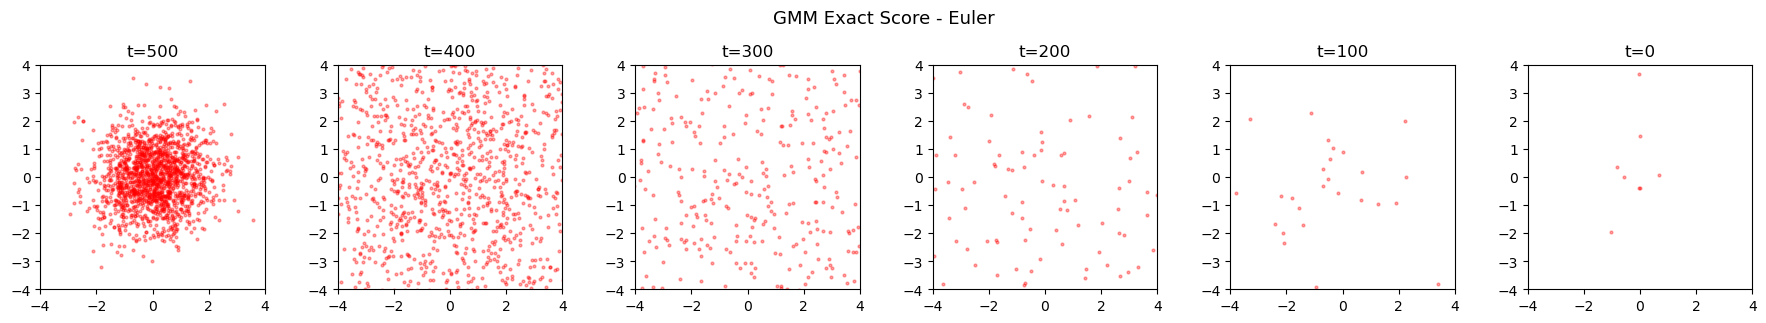

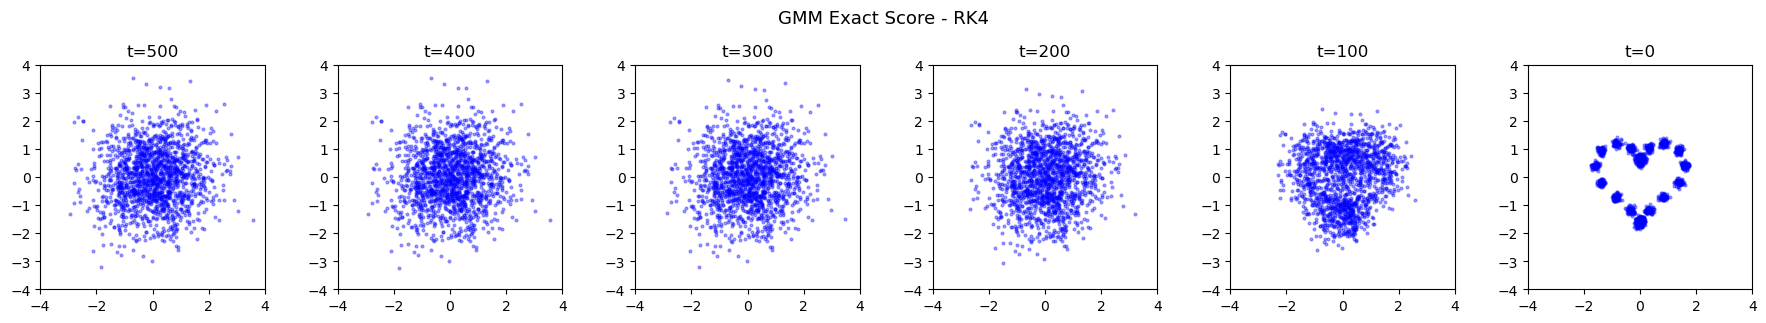

In [17]:
# Heart: GMM 모드들 (make_heart와 동일한 중심점)
_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
H_MEANS = (
    np.c_[
        16 * np.sin(_t) ** 3,
        13 * np.cos(_t) - 5 * np.cos(2 * _t) - 2 * np.cos(3 * _t) - np.cos(4 * _t),
    ]
    / 10
)  # (20,2)
H_VAR = 0.07**2


def gmm_score(x, t_idx):
    ab = alpha_bar[t_idx]
    s2 = sigma2_t[t_idx]
    mu_t = np.sqrt(ab) * H_MEANS  # (K,2)
    var_t = ab * H_VAR + s2  # scalar

    diff = x[:, None, :] - mu_t[None, :, :]  # (N,K,2)
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    wk /= wk.sum(1, keepdims=True)

    score_k = -diff / var_t  # (N,K,2)
    return (wk[:, :, None] * score_k).sum(1)  # (N,2)


def plot_steps(traj, steps=None, color="#3498db", title=""):
    """단일 방법의 스텝별 분포 시각화 (T→0 순서)"""
    if steps is None:
        steps = sorted(traj.keys(), reverse=True)
    steps = list(steps)
    fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
    for ax, t in zip(axes, steps):
        pts = traj.get(t, None)
        if pts is not None:
            ax.scatter(*pts.T, s=4, alpha=0.35, c=color)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(f"t={t}")
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


x_T = fwd["heart"][T].copy()
traj_e0 = reverse_euler(x_T, gmm_score)
traj_r0 = reverse_rk4(x_T, gmm_score)

plot_steps(traj_e0, steps=reversed(SAVE_STEPS), color="red", title="GMM Exact Score - Euler")
plot_steps(traj_r0, steps=reversed(SAVE_STEPS), color="blue", title="GMM Exact Score - RK4")

## GMM Exact Score 증명
---

주어진 데이터 $x_0$가 GMM(Gaussian Mixture Model)이라 가정:
$$
p_0(x_0)=\frac{1}{K} \sum_{k=1}^{K} \mathcal{N}(x_0;\mu_k,\sigma_k^2 I)
$$



1. GMM marginal $p_t(x)$ 유도
    출발점: $x_0 \sim p_0$이고, forward process로 인해

    $$x_t \mid x_0 \sim \mathcal{N}(\sqrt{\bar\alpha_t},x_0,;\sigma_t^2 I), \qquad \sigma_t^2 = 1-\bar\alpha_t$$

    전체 확률 법칙으로 $x_0$를 marginalize:

    $$p_t(x) = \int p(x \mid x_0)p_0(x_0)dx_0$$

    $p_0$가 GMM이면:

    $$p_t(x) = \int \mathcal{N}(x;\sqrt{\bar\alpha_t}x_0,\sigma_t^2 I) \cdot \frac{1}{K}\sum_k \mathcal{N}(x_0;\mu_k,\sigma_k^2 I)dx_0$$

    합산과 적분 순서를 바꾸면:

    $$= \frac{1}{K}\sum_k \underbrace{\int \mathcal{N}(x;\sqrt{\bar\alpha_t}x_0,\sigma_t^2 I)\cdot\mathcal{N}(x_0;\mu_k,\sigma_k^2 I)dx_0}_{\text{이 적분 하나만 계산하면 됨}}$$

    이 적분은 가우시안 convolution. $x_0 \sim \mathcal{N}(\mu_k, \sigma_k^2)$이고 $x = \sqrt{\bar\alpha_t}x_0 + \epsilon$, $\epsilon \sim \mathcal{N}(0,\sigma_t^2)$ 이면:

    $$x \sim \mathcal{N}(\sqrt{\bar\alpha_t}\mu_k,;\bar\alpha_t\sigma_k^2 + \sigma_t^2)$$

    따라서:

    $$\boxed{p_t(x) = \frac{1}{K}\sum_k \mathcal{N}(x;\sqrt{\bar\alpha_t}\mu_k,;\bar\alpha_t\sigma_k^2+\sigma_t^2)}$$
---
2. Score $\nabla_x \log p_t(x)$ 유도
    $p_t$를 알고 있으니 log를 취하고 미분하면 되는데, 합의 log는 바로 미분이 안 됨.

    $\log$를 먼저 분리:

    $$\log p_t(x) = \log \sum_k \underbrace{\frac{1}{K}\mathcal{N}(x;\mu_k^t, v_k^t)}_{=p_t^{(k)}(x)}$$

    $\nabla_x$를 취하면 (log-sum 미분):

    $$\nabla_x \log p_t(x) = \frac{\nabla_x \sum_k p_t^{(k)}(x)}{\sum_k p_t^{(k)}(x)} = \sum_k \underbrace{\frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}}_{=w_k(x,t)} \cdot \nabla_x \log p_t^{(k)}(x)$$

    $$
    w_k
    =
    \frac{
    k\text{번째 Gaussian이 현재 }x\text{에 부여하는 밀도}
    }{
    \text{모든 Gaussian이 현재 }x\text{에 부여하는 밀도의 총합}
    }
    $$
    : 현재 점 x를 봤을 때, k번째 Gaussian이 얼마나 강하게 설명하는지

    각 가우시안의 score는 쉽게 계산됨 ($\mu_k^t = \sqrt{\bar\alpha_t}\mu_k$, $v_k^t = \bar\alpha_t\sigma_k^2 + \sigma_t^2$):

    $$\nabla_x \log \mathcal{N}(x;\mu_k^t, v_k^t) = -\frac{x - \mu_k^t}{v_k^t}$$

    최종:

    $$\boxed{s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar\alpha_t\sigma_k^2+\sigma_t^2}\right)}$$


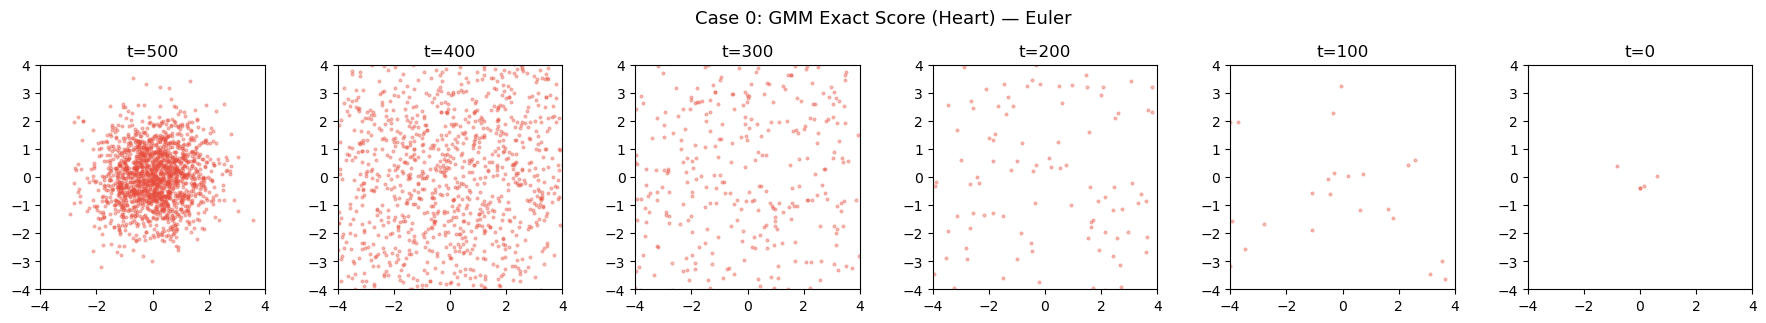

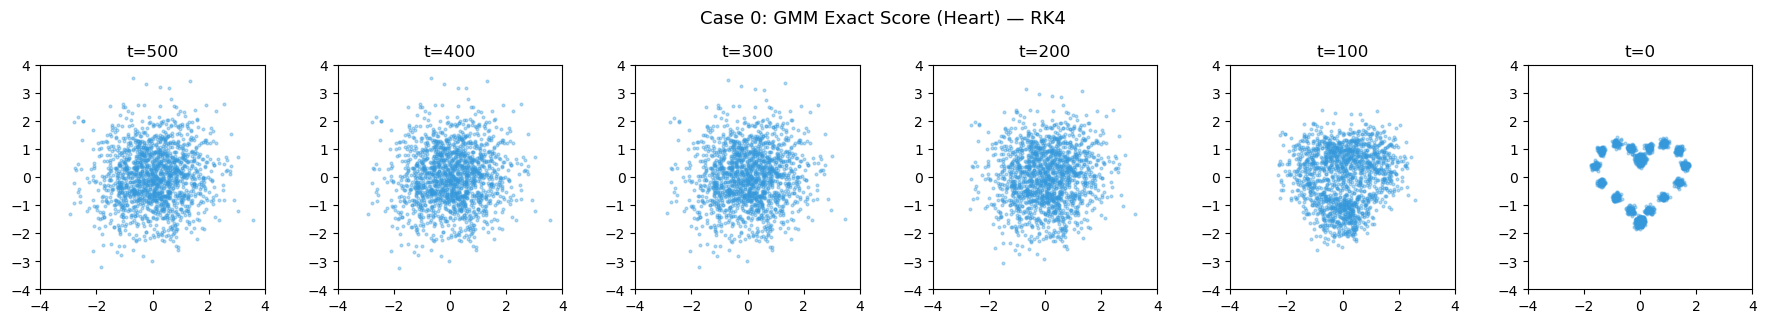

In [12]:
# Heart: GMM 모드들 (make_heart와 동일한 중심점)
_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
H_MEANS = (
    np.column_stack([
        16 * np.sin(_t) ** 3,
        13 * np.cos(_t) - 5 * np.cos(2 * _t) - 2 * np.cos(3 * _t) - np.cos(4 * _t),
    ])
    / 10
)  # (20,2)
H_VAR = 0.07**2


def gmm_score(x, t_idx):
    ab = alpha_bar[t_idx]
    s2 = sigma2_t[t_idx]
    mu_t = np.sqrt(ab) * H_MEANS  # (K,2)
    var_t = ab * H_VAR + s2  # scalar

    diff = x[:, None, :] - mu_t[None, :, :]  # (N,K,2)
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    wk /= wk.sum(1, keepdims=True)

    score_k = -diff / var_t  # (N,K,2)
    return (wk[:, :, None] * score_k).sum(1)  # (N,2)


x_T = fwd["heart"][T].copy()
traj_e0 = reverse_euler(x_T, gmm_score)
traj_r0 = reverse_rk4(x_T, gmm_score)

plot_steps(traj_e0, title="Case 0: GMM Exact Score (Heart) — Euler", color="#e74c3c")
plot_steps(traj_r0, title="Case 0: GMM Exact Score (Heart) — RK4",   color="#3498db")